Installation and Imports

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import ops
from sklearn.metrics import r2_score

os.environ["KERAS_BACKEND"] = "torch"      # must be set BEFORE importing keras ('jax' was ~6x faster/epoch in my CPU test)
print("Keras", keras.__version__, "| backend:", keras.backend.backend())

Keras 3.13.2 | backend: tensorflow


Load and clean the dataset

In [ ]:
excel_path = "/content/FinalDataNN.xlsx"
df = pd.read_excel(excel_path)

df_cleaned = df.dropna(subset=["P", "Y", "Ptest", "Ytest"])

P_train = df_cleaned["P"].values.astype("float32")
Y_train = df_cleaned["Y"].values.astype("float32")
P_test = df_cleaned["Ptest"].values.astype("float32")
Y_test = df_cleaned["Ytest"].values.astype("float32")

print(f"Train set size: {len(P_train)} samples")
print(f"Test set size: {len(P_test)} samples")

Train set size: 1072 samples
Test set size: 1072 samples


Hyper-parameters

In [ ]:
Spline_Order = 3   # Spline order of every KANLinear (B-spline)
Grid_Size = 3   # Grid size of every KANLinear
N_Sub_KANs = 3   # number of KAN sub-layers (RKAN memories) inside each TKAN cell
Batch_Size  = 32
Context_Len = 120
Pred_Len    = 20
H_Dims      = 32
N_Epochs    = 500
Learning_Rate = 3e-4
Seq_Step = 5
Num_Layers  = 2
Bidirectional = False

Displaying Time Series

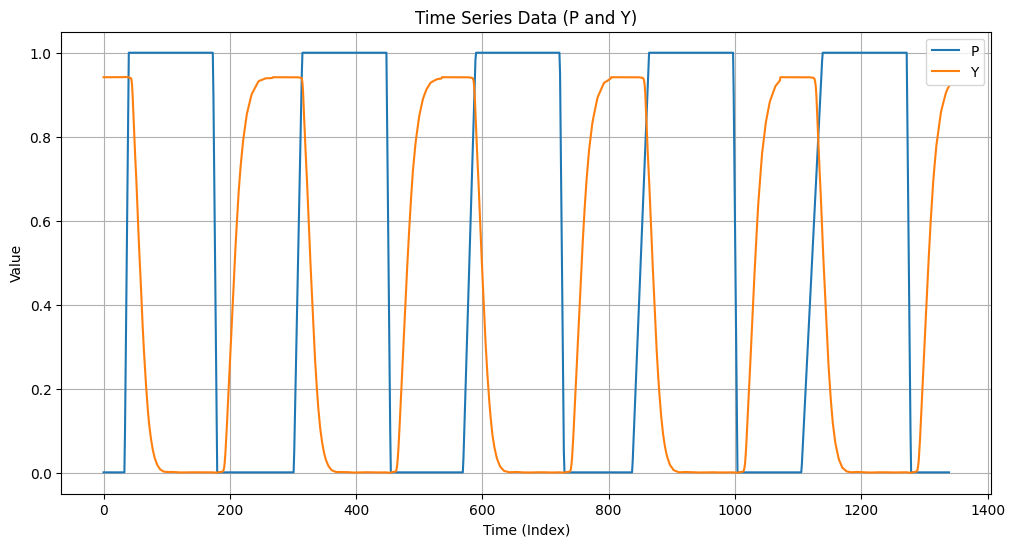

In [ ]:
time_series_data_P = df["P"]
time_series_data_Y = df["Y"]

plt.figure(figsize=(12, 6))
plt.plot(time_series_data_P, label="P")
plt.plot(time_series_data_Y, label="Y")
plt.title("Time Series Data (P and Y)")
plt.xlabel("Time (Index)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

Sliding-window dataset (P → Y), as NumPy arrays

In [ ]:
def make_windows(x_series, y_series, context_len=Context_Len, pred_len=Pred_Len):
    """Sliding windows: x[i : i+context_len]  ->  y[i+context_len : i+context_len+pred_len]"""
    total_len = context_len + pred_len
    n = max(len(x_series) - total_len + 1, 0)
    X = np.array([x_series[i: i + context_len] for i in range(n)], dtype="float32").reshape(n, context_len)
    Y = np.array([y_series[i + context_len: i + total_len] for i in range(n)], dtype="float32").reshape(n, pred_len)
    return X, Y

X_train, Yw_train = make_windows(P_train, Y_train)
X_test, Yw_test = make_windows(P_test, Y_test)

print(f"Train windows: {len(X_train)}")
print(f"Test windows: {len(X_test)}")

Train windows: 933
Test windows: 933


KAN layer (B-spline KANLinear, Keras 3 port of `keras_efficient_kan` used by TKAN)

In [ ]:
class GridInitializer(keras.initializers.Initializer):
    """Uniform knot grid, repeated for every input feature (as in keras_efficient_kan)."""
    def __init__(self, grid_range, grid_size, spline_order):
        self.grid_range = list(grid_range)
        self.grid_size = grid_size
        self.spline_order = spline_order

    def __call__(self, shape, dtype=None):
        h = (self.grid_range[1] - self.grid_range[0]) / self.grid_size
        start = -self.spline_order * h + self.grid_range[0]
        stop = (self.grid_size + self.spline_order) * h + self.grid_range[0]
        grid = np.linspace(start, stop, self.grid_size + 2 * self.spline_order + 1, dtype=np.float32)
        grid = np.tile(grid, (shape[1], 1))[None]                       # (1, in, G+2K+1)
        return ops.convert_to_tensor(grid, dtype=dtype)

    def get_config(self):
        return {"grid_range": self.grid_range, "grid_size": self.grid_size, "spline_order": self.spline_order}


class KANLinear(keras.layers.Layer):
    """B-spline KAN layer (LayerNorm -> ReLU base linear + B-spline linear).
    Port of keras_efficient_kan.KANLinear (same math, only public Keras APIs)."""
    def __init__(self, units, grid_size=Grid_Size, spline_order=Spline_Order, base_activation="relu",
                 grid_range=(-1, 1), use_bias=True, use_layernorm=True, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.grid_size = grid_size
        self.spline_order = spline_order
        self.base_activation_name = base_activation
        self.grid_range = list(grid_range)
        self.use_bias = use_bias
        self.use_layernorm = use_layernorm
        self.layer_norm = keras.layers.LayerNormalization(axis=-1) if use_layernorm else None

    def build(self, input_shape):
        self.in_features = input_shape[-1]
        self.grid = self.add_weight(
            name="grid", shape=[1, self.in_features, self.grid_size + 2 * self.spline_order + 1],
            initializer=GridInitializer(self.grid_range, self.grid_size, self.spline_order), trainable=False)
        self.base_weight = self.add_weight(
            name="base_weight", shape=[self.in_features, self.units], initializer="glorot_uniform")
        if self.use_bias:
            self.base_bias = self.add_weight(name="base_bias", shape=[self.units], initializer="zeros")
        self.spline_weight = self.add_weight(
            name="spline_weight", shape=[self.in_features * (self.grid_size + self.spline_order), self.units],
            initializer="glorot_uniform")
        if self.use_layernorm:
            self.layer_norm.build(input_shape)
        self.built = True

    def b_splines(self, x):
        xe = ops.expand_dims(x, -1)
        bases = ops.cast((xe >= self.grid[..., :-1]) & (xe < self.grid[..., 1:]), x.dtype)
        for k in range(1, self.spline_order + 1):
            left = (xe - self.grid[..., :-(k + 1)]) / (self.grid[..., k:-1] - self.grid[..., :-(k + 1)])
            right = (self.grid[..., k + 1:] - xe) / (self.grid[..., k + 1:] - self.grid[..., 1:-k])
            bases = left * bases[..., :-1] + right * bases[..., 1:]
        return ops.reshape(bases, [ops.shape(x)[0], -1])

    def call(self, x):
        if self.use_layernorm:
            x = self.layer_norm(x)
        base = ops.matmul(getattr(ops, self.base_activation_name)(x), self.base_weight)
        if self.use_bias:
            base = base + self.base_bias
        return base + ops.matmul(self.b_splines(x), self.spline_weight)

    def compute_output_shape(self, input_shape):
        return tuple(input_shape[:-1]) + (self.units,)

    def get_config(self):
        cfg = super().get_config()
        cfg.update(units=self.units, grid_size=self.grid_size, spline_order=self.spline_order,
                   base_activation=self.base_activation_name, grid_range=self.grid_range,
                   use_bias=self.use_bias, use_layernorm=self.use_layernorm)
        return cfg

TKAN cell and layer (Keras RNN)

In [ ]:
class TKANCellNoGF(keras.layers.Layer):
    """One TKAN time-step (Keras 3, backend-agnostic) with the Global Feedback removed.

    Original TKANCell has two feedback paths:
      (a) local  : every KAN sub-layer feeds its own state back into itself   -> KEPT
      (b) global : the cell output h_{t-1} feeds back into the gates i, f, c~ -> REMOVED
                   (no `recurrent_kernel`, no recurrent dropout)
    Gates depend on x_t only. Memory = cell state c_t + the sub-layer states.
    States: [c, sub_state_1, ..., sub_state_n].
    """
    def __init__(self, units, sub_kan_configs=None, sub_kan_output_dim=None, sub_kan_input_dim=None,
                 activation="tanh", recurrent_activation="sigmoid", use_bias=True,
                 kernel_initializer="glorot_uniform", recurrent_initializer="orthogonal",
                 bias_initializer="zeros", unit_forget_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.sub_kan_configs = sub_kan_configs or [None]
        self.sub_kan_output_dim = sub_kan_output_dim
        self.sub_kan_input_dim = sub_kan_input_dim
        self.activation = keras.activations.get(activation)
        self.recurrent_activation = keras.activations.get(recurrent_activation)
        self.use_bias = use_bias
        self.kernel_initializer = keras.initializers.get(kernel_initializer)
        self.recurrent_initializer = keras.initializers.get(recurrent_initializer)
        self.bias_initializer = keras.initializers.get(bias_initializer)
        self.unit_forget_bias = unit_forget_bias
        self.state_size = [units] + [1 for _ in self.sub_kan_configs]   # sizes fixed in get_initial_state
        self.output_size = units

    def build(self, input_shape):
        input_dim = input_shape[-1]
        if self.sub_kan_input_dim is None:
            self.sub_kan_input_dim = input_dim
        if self.sub_kan_output_dim is None:
            self.sub_kan_output_dim = input_dim
        n_sub = len(self.sub_kan_configs)

        # gates i, f, c~ : x_t -> 3*units      (NO recurrent_kernel: h_{t-1} is not used)
        self.kernel = self.add_weight(shape=(input_dim, self.units * 3), name="kernel",
                                      initializer=self.kernel_initializer)
        if self.use_bias:
            if self.unit_forget_bias:
                def bias_initializer(_, *args, **kwargs):
                    return ops.concatenate([
                        self.bias_initializer((self.units,), *args, **kwargs),
                        keras.initializers.get("ones")((self.units,), *args, **kwargs),
                        self.bias_initializer((self.units,), *args, **kwargs)])
            else:
                bias_initializer = self.bias_initializer
            self.bias = self.add_weight(shape=(self.units * 3,), name="bias", initializer=bias_initializer)
        else:
            self.bias = None

        # RKAN sub-layers with local memory
        self.tkan_sub_layers = []
        for config in self.sub_kan_configs:
            if config is None:
                layer = KANLinear(self.sub_kan_output_dim)
            elif isinstance(config, (int, float)):
                layer = KANLinear(self.sub_kan_output_dim, spline_order=config)
            elif isinstance(config, dict):
                layer = KANLinear(self.sub_kan_output_dim, **config)
            else:
                layer = keras.layers.Dense(self.sub_kan_output_dim, activation=config)
            layer.build((input_shape[0], self.sub_kan_input_dim))
            self.tkan_sub_layers.append(layer)

        self.sub_tkan_kernel = self.add_weight(
            shape=(n_sub, self.sub_kan_output_dim * 2), name="sub_tkan_kernel",
            initializer=self.recurrent_initializer)
        self.sub_tkan_recurrent_kernel_inputs = self.add_weight(
            shape=(n_sub, input_dim, self.sub_kan_input_dim), name="sub_tkan_recurrent_kernel_inputs",
            initializer=self.recurrent_initializer)
        self.sub_tkan_recurrent_kernel_states = self.add_weight(
            shape=(n_sub, self.sub_kan_output_dim, self.sub_kan_input_dim), name="sub_tkan_recurrent_kernel_states",
            initializer=self.recurrent_initializer)
        self.aggregated_weight = self.add_weight(
            shape=(n_sub * self.sub_kan_output_dim, self.units), name="aggregated_weight",
            initializer="glorot_uniform")
        self.aggregated_bias = self.add_weight(
            shape=(self.units,), name="aggregated_bias", initializer="zeros")
        self.built = True

    def call(self, inputs, states, training=None):
        c_tm1, sub_states = states[0], states[1:]

        gates = ops.matmul(inputs, self.kernel)
        if self.use_bias:
            gates = gates + self.bias
        i, f, g = ops.split(self.recurrent_activation(gates), 3, axis=-1)
        c = f * c_tm1 + i * self.activation(g)

        sub_outputs, new_sub_states = [], []
        for idx, (sub_layer, sub_state) in enumerate(zip(self.tkan_sub_layers, sub_states)):
            agg_input = (ops.matmul(inputs, self.sub_tkan_recurrent_kernel_inputs[idx])
                         + ops.matmul(sub_state, self.sub_tkan_recurrent_kernel_states[idx]))   # local feedback (kept)
            sub_output = sub_layer(agg_input)
            k_h, k_x = ops.split(self.sub_tkan_kernel[idx], 2, axis=0)
            new_sub_states.append(k_h * sub_output + sub_state * k_x)
            sub_outputs.append(sub_output)

        aggregated = ops.matmul(ops.concatenate(sub_outputs, axis=-1), self.aggregated_weight) + self.aggregated_bias
        o = self.recurrent_activation(aggregated)
        h = o * self.activation(c)
        return h, [c] + new_sub_states

    def get_initial_state(self, inputs=None, batch_size=None, dtype=None):
        dtype = dtype or self.compute_dtype
        return [ops.zeros((batch_size, self.units), dtype=dtype)] + \
               [ops.zeros((batch_size, self.sub_kan_output_dim), dtype=dtype) for _ in self.sub_kan_configs]

    def get_config(self):
        cfg = super().get_config()
        cfg.update(units=self.units, sub_kan_configs=self.sub_kan_configs,
                   sub_kan_output_dim=self.sub_kan_output_dim, sub_kan_input_dim=self.sub_kan_input_dim,
                   activation=keras.activations.serialize(self.activation),
                   recurrent_activation=keras.activations.serialize(self.recurrent_activation),
                   use_bias=self.use_bias, unit_forget_bias=self.unit_forget_bias)
        return cfg


class TKAN(keras.layers.RNN):
    """TKAN layer (Keras RNN wrapper around TKANCellNoGF). Input (B, T, F) -> (B, T, units) or (B, units)."""
    def __init__(self, units, sub_kan_configs=None, sub_kan_output_dim=None, sub_kan_input_dim=None,
                 return_sequences=False, return_state=False, go_backwards=False, stateful=False,
                 unroll=False, **kwargs):
        cell = TKANCellNoGF(units, sub_kan_configs=sub_kan_configs,
                            sub_kan_output_dim=sub_kan_output_dim, sub_kan_input_dim=sub_kan_input_dim)
        super().__init__(cell, return_sequences=return_sequences, return_state=return_state,
                         go_backwards=go_backwards, stateful=stateful, unroll=unroll, **kwargs)
        self.input_spec = [keras.layers.InputSpec(ndim=3)]

    def inner_loop(self, sequences, initial_state, mask, training=False):
        if isinstance(mask, (list, tuple)):
            mask = mask[0]
        return super().inner_loop(sequences, initial_state, mask=mask, training=training)

    def call(self, sequences, initial_state=None, mask=None, training=False):
        return super().call(sequences, mask=mask, training=training, initial_state=initial_state)

    def get_config(self):
        c = self.cell
        cfg = {"units": c.units, "sub_kan_configs": c.sub_kan_configs,
               "sub_kan_output_dim": c.sub_kan_output_dim, "sub_kan_input_dim": c.sub_kan_input_dim,
               "return_sequences": self.return_sequences, "return_state": self.return_state,
               "go_backwards": self.go_backwards, "stateful": self.stateful, "unroll": self.unroll}
        base = super().get_config()
        del base["cell"]
        return {**base, **cfg}

    @classmethod
    def from_config(cls, config):
        return cls(**config)

Main model: TKAN (stacked layers + Dense read-out)

In [ ]:
def build_tkan_model(context_len, pred_len, hidden, seq_step, num_layers, n_sub_kans, g, k):
    assert context_len % seq_step == 0, "context_len must be a multiple of seq_step"
    num_steps = context_len // seq_step
    sub_cfgs = [{"grid_size": g, "spline_order": k} for _ in range(n_sub_kans)]

    inp = keras.Input(shape=(context_len,))
    x = keras.layers.Reshape((num_steps, seq_step))(inp)
    for l in range(num_layers):
        x = TKAN(hidden, sub_kan_configs=sub_cfgs, return_sequences=(l < num_layers - 1))(x)
    out = keras.layers.Dense(pred_len)(x)
    return keras.Model(inp, out, name="TKAN")

Training utilities

In [ ]:
def compute_stats(Y_true, Y_pred):
    err = Y_pred - Y_true
    mae = np.mean(np.abs(err))
    mse = np.mean(err ** 2)
    rmse = np.sqrt(mse)

    # R2 Score
    r2 = r2_score(Y_true, Y_pred)

    # SNR (Signal-to-Noise Ratio in dB)
    signal_power = np.mean(Y_true**2)
    noise_power = mse
    snr_db = 10 * np.log10(signal_power / noise_power) if noise_power != 0 else np.inf

    # SMAPE (Symmetric Mean Absolute Percentage Error)
    smape_numerator = np.abs(Y_pred - Y_true)
    smape_denominator = (np.abs(Y_true) + np.abs(Y_pred)) / 2
    # Handle cases where denominator is zero to avoid NaNs/Infs
    smape = np.mean(np.where(smape_denominator == 0, 0, smape_numerator / smape_denominator)) * 100

    # NRMSE (Normalized Root Mean Squared Error)
    # Range-normalized NRMSE
    y_range = np.max(Y_true) - np.min(Y_true)
    nrmse_range = (rmse / y_range) * 100 if y_range != 0 else np.inf

    # Standard-deviation-normalized NRMSE
    y_std = np.std(Y_true)
    nrmse_std = (rmse / y_std) * 100 if y_std != 0 else np.inf

    # Pointwise relative error (unstable, for reference)
    relative_error_abs_val_true = np.abs(Y_true)
    # Avoid division by zero, set error to 0 if true value is near zero
    pointwise_rel_err = np.where(
        relative_error_abs_val_true < 1e-8,
        0,
        np.abs(Y_pred - Y_true) / relative_error_abs_val_true
    ) * 100
    mean_pointwise_rel_err = np.mean(pointwise_rel_err)

    return mae, mse, rmse, r2, snr_db, smape, nrmse_range, nrmse_std, mean_pointwise_rel_err

def compute_stats_for_history(X, Y, model):
    pred = model.predict(X, batch_size=Batch_Size, verbose=0)
    mae, mse, rmse, r2, snr_db, smape, nrmse_range, nrmse_std, mean_pointwise_rel_err = compute_stats(Y, pred)
    return mae, mse, rmse


Model, optimizer, loss

In [ ]:
print("Backend:", keras.backend.backend())

model = build_tkan_model(
    context_len=Context_Len,
    pred_len=Pred_Len,
    hidden=H_Dims,
    seq_step=Seq_Step,
    num_layers=Num_Layers,
    n_sub_kans=N_Sub_KANs,
    g=Grid_Size,
    k=Spline_Order
)
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=Learning_Rate, weight_decay=0.01),  # 0.01 = torch AdamW default
    loss="mae",                                                                        # == nn.L1Loss
)
model.summary()

Backend: tensorflow


Model: "TKAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 24, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tkan_2 (TKAN)                   │ (None, 24, 32)         │         1,988 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tkan_3 (TKAN)                   │ (None, 32)             │        35,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,008 (148.47 KB)

 Trainable params: 36,898 (144.13 KB)

 Non-trainable params: 1,110 (4.34 KB)

Training loop with timing (Keras `fit` + callback)

In [ ]:
train_history = []
test_history = []
train_times = []
infer_times = []
per_iteration_train_times = []
total_train_time = 0.0


class EpochStats(keras.callbacks.Callback):
    """Reproduces the per-epoch bookkeeping / timing / printing of the original training loop."""
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.perf_counter()

    def on_train_batch_begin(self, batch, logs=None):
        self.iter_start = time.perf_counter()

    def on_train_batch_end(self, batch, logs=None):
        per_iteration_train_times.append(time.perf_counter() - self.iter_start)

    def on_epoch_end(self, epoch, logs=None):
        global total_train_time
        epoch_time = time.perf_counter() - self.epoch_start
        train_times.append(epoch_time)
        total_train_time += epoch_time

        # Get predictions for train and test sets
        train_pred = self.model.predict(X_train, batch_size=Batch_Size, verbose=0)
        test_pred = self.model.predict(X_test, batch_size=Batch_Size, verbose=0)

        # Compute stats using the new compute_stats signature
        train_mae, train_mse, train_rmse, train_r2, train_snr_db, train_smape, train_nrmse_range, train_nrmse_std, train_pointwise_rel_err = compute_stats(Yw_train, train_pred)
        test_mae, test_mse, test_rmse, test_r2, test_snr_db, test_smape, test_nrmse_range, test_nrmse_std, test_pointwise_rel_err = compute_stats(Yw_test, test_pred)

        train_history.append((train_mae, train_mse))
        test_history.append((test_mae, test_mse))

        infer_start = time.perf_counter()
        # The infer_time for this epoch should be based on a single prediction run, typically test set
        _ = self.model.predict(X_test, batch_size=Batch_Size, verbose=0)
        infer_time = time.perf_counter() - infer_start
        infer_times.append(infer_time)

        print(
            f"Epoch {epoch + 1:04d} | "
            f"Loss {logs['loss']:.6f} | "
            f"Train MAE {train_mae:.6f} | Train MSE {train_mse:.6f} | "
            f"Test MAE {test_mae:.6f} | Test MSE {test_mse:.6f} | "
            f"Train time {epoch_time:.2f}s | Inference time {infer_time:.2f}s"
        )


model.fit(
    X_train, Yw_train,
    batch_size=Batch_Size,
    epochs=N_Epochs,
    shuffle=True,
    callbacks=[EpochStats()],
    verbose=0,
)

Epoch 0001 | Loss 0.293828 | Train MAE 0.247429 | Train MSE 0.154743 | Test MAE 0.241857 | Test MSE 0.150399 | Train time 0.88s | Inference time 0.26s
Epoch 0002 | Loss 0.215485 | Train MAE 0.179418 | Train MSE 0.097703 | Test MAE 0.175515 | Test MSE 0.095008 | Train time 0.73s | Inference time 0.24s
Epoch 0003 | Loss 0.147982 | Train MAE 0.119420 | Train MSE 0.060569 | Test MAE 0.116826 | Test MSE 0.058846 | Train time 0.72s | Inference time 0.24s
Epoch 0004 | Loss 0.102018 | Train MAE 0.084975 | Train MSE 0.038000 | Test MAE 0.083284 | Test MSE 0.036904 | Train time 0.73s | Inference time 0.28s
Epoch 0005 | Loss 0.074305 | Train MAE 0.063547 | Train MSE 0.023026 | Test MAE 0.062466 | Test MSE 0.022368 | Train time 0.78s | Inference time 0.24s
Epoch 0006 | Loss 0.055664 | Train MAE 0.047268 | Train MSE 0.013250 | Test MAE 0.046544 | Test MSE 0.012880 | Train time 0.71s | Inference time 0.25s
Epoch 0007 | Loss 0.041643 | Train MAE 0.035541 | Train MSE 0.007932 | Test MAE 0.035169 | Tes

Final evaluation & speed-up

In [ ]:
final_train_mae, final_train_mse, final_train_rmse, final_train_r2, final_train_snr_db, final_train_smape, final_train_nrmse_range, final_train_nrmse_std, final_train_pointwise_rel_err = compute_stats(Yw_train, model.predict(X_train, batch_size=Batch_Size, verbose=0))
final_test_mae, final_test_mse, final_test_rmse, final_test_r2, final_test_snr_db, final_test_smape, final_test_nrmse_range, final_test_nrmse_std, final_test_pointwise_rel_err = compute_stats(Yw_test, model.predict(X_test, batch_size=Batch_Size, verbose=0))

def physics_simulation(x_batch):
    time.sleep(0.0001 * x_batch.shape[0])

n_test_batches = int(np.ceil(len(X_test) / Batch_Size))
physics_start = time.perf_counter()
for i in range(0, len(X_test), Batch_Size):
    physics_simulation(X_test[i: i + Batch_Size])
physics_time = time.perf_counter() - physics_start

avg_infer_time = np.mean(infer_times)
speedup = physics_time / (avg_infer_time * n_test_batches)

def count_parameters(model):
    return sum(int(np.prod(w.shape)) for w in model.trainable_weights)

structure = " -> ".join(f"{l.name}{tuple(l.output.shape)}" for l in model.layers)

results_df = pd.DataFrame({
    "Metric": [
        "Train MAE", "Test MAE",
        "Train MSE", "Test MSE",
        "Train RMSE", "Test RMSE",
        "Train R2", "Test R2",
        "Train SNR (dB)", "Test SNR (dB)",
        "Train SMAPE (%)", "Test SMAPE (%)",
        "Train NRMSE, range-normalized (%)", "Test NRMSE, range-normalized (%)",
        "Train NRMSE, std-normalized (%)", "Test NRMSE, std-normalized (%)",
        "[reference only, unstable] Train pointwise rel. error (%)",
        "[reference only, unstable] Test pointwise rel. error (%)",
        "[PLACEHOLDER, not physical] Speedup (sleep-proxy / GFKAN)",
        "Total Training Time (s)",
        "Test Time (s)",
        "Average Epoch Training Time (s)",
        "Per-Iteration Training Time (s)",
        "Total number of trainable parameters",
        "Epochs Run",
        "Structure"
    ],
    "Value": [
        final_train_mae, final_test_mae,
        final_train_mse, final_test_mse,
        final_train_rmse, final_test_rmse,
        final_train_r2, final_test_r2,
        final_train_snr_db, final_test_snr_db,
        final_train_smape, final_test_smape,
        final_train_nrmse_range, final_test_nrmse_range,
        final_train_nrmse_std, final_test_nrmse_std,
        final_train_pointwise_rel_err, final_test_pointwise_rel_err,
        speedup,
        total_train_time,
        np.mean(infer_times),
        total_train_time / N_Epochs,
        np.mean(per_iteration_train_times),
        count_parameters(model),
        N_Epochs,
        structure
    ]
})

print("\n--- Summary of Results (Markdown) ---")
print(results_df.to_markdown(index=False))


--- Summary of Results (Markdown) ---
| Metric                                                    | Value                                                                                                               |
|:----------------------------------------------------------|:--------------------------------------------------------------------------------------------------------------------|
| Train MAE                                                 | 0.004066768568009138                                                                                                |
| Test MAE                                                  | 0.0037253741174936295                                                                                               |
| Train MSE                                                 | 8.526843885192648e-05                                                                                               |
| Test MSE                                                  |

Plot training history

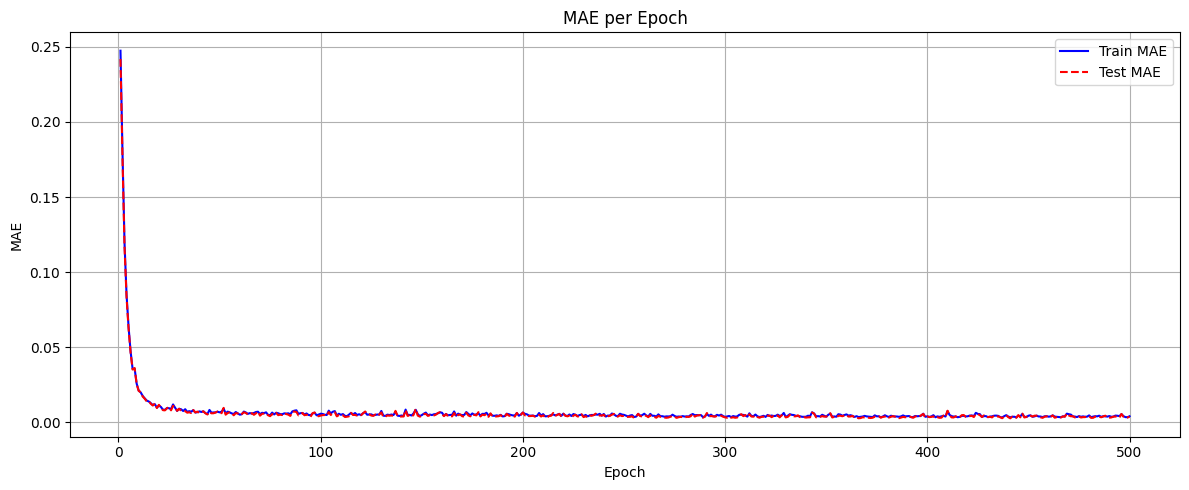

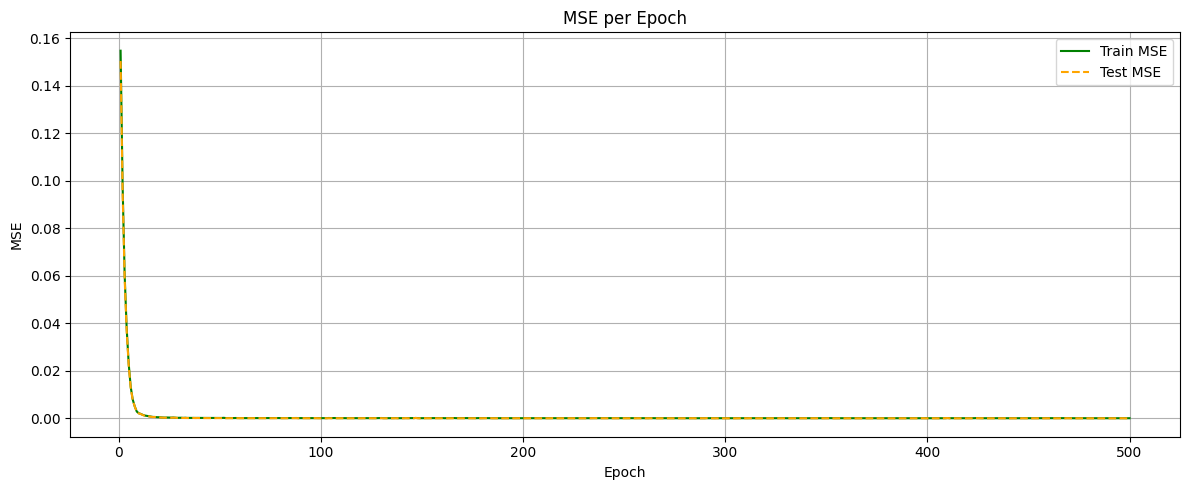

In [ ]:
epochs = range(1, N_Epochs + 1)
train_mae_hist = [h[0] for h in train_history]
train_mse_hist = [h[1] for h in train_history]
test_mae_hist = [h[0] for h in test_history]
test_mse_hist = [h[1] for h in test_history]

plt.figure(figsize=(12, 5))
plt.plot(epochs, train_mae_hist, label="Train MAE", color="blue")
plt.plot(epochs, test_mae_hist, label="Test MAE", color="red", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("MAE per Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(epochs, train_mse_hist, label="Train MSE", color="green")
plt.plot(epochs, test_mse_hist, label="Test MSE", color="orange", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE per Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Full test-set prediction vs ground truth

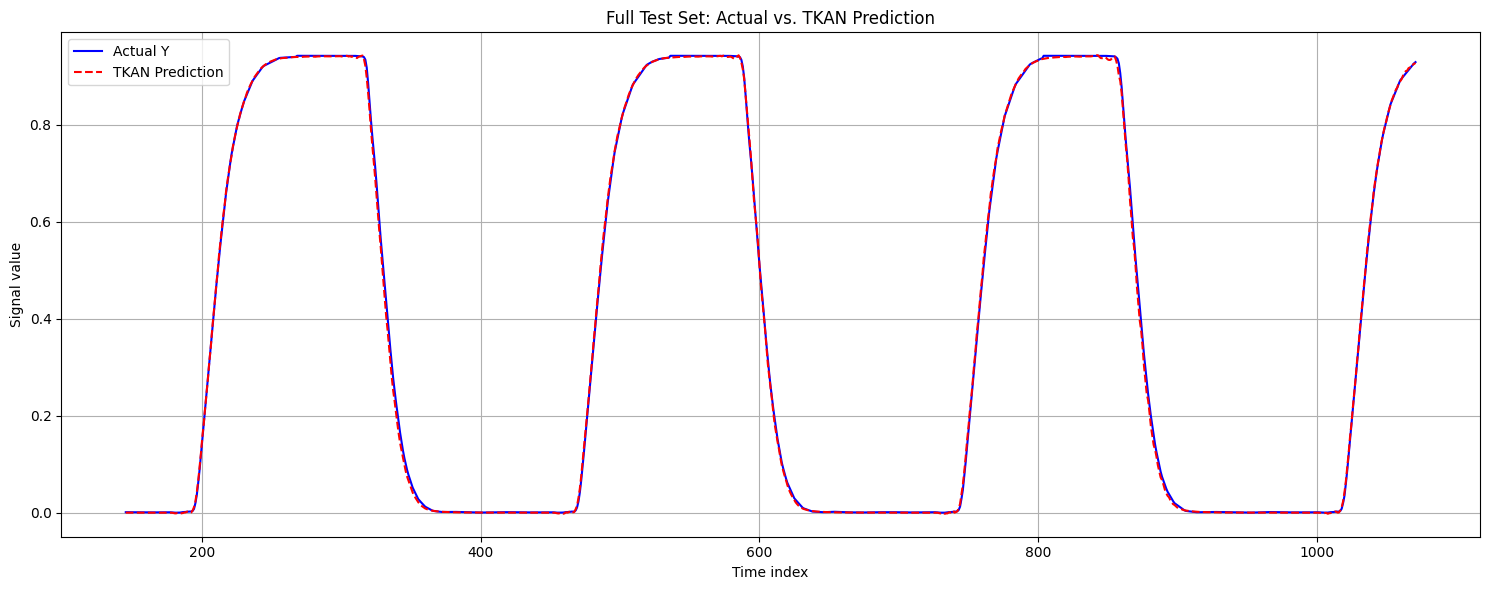

In [ ]:
full_predicted_Y_test = np.full_like(Y_test, np.nan, dtype=np.float64)
preds = model.predict(X_test, batch_size=Batch_Size, verbose=0)

for idx in range(len(X_test)):
    start_idx = idx + Context_Len
    end_idx = start_idx + Pred_Len
    if start_idx < len(Y_test):
        full_predicted_Y_test[start_idx:min(end_idx, len(Y_test))] = preds[idx][:min(Pred_Len, len(Y_test) - start_idx)]

start_plot = 145
plt.figure(figsize=(15, 6))
plt.plot(np.arange(start_plot, len(Y_test)), Y_test[start_plot:], label="Actual Y", color="blue")
plt.plot(np.arange(start_plot, len(full_predicted_Y_test)), full_predicted_Y_test[start_plot:],
         label="TKAN Prediction", color="red", linestyle="--")
plt.xlabel("Time index")
plt.ylabel("Signal value")
plt.title("Full Test Set: Actual vs. TKAN Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()